CE888 DATA SCIENCE PROJECT

In [1]:
# import basic libraries
import warnings
warnings.filterwarnings('ignore')

In [2]:
#import basic libraries
! pip install statsmodels
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# the Directory containing  CSV files
csv_dir = 'weatherdata_for_students/' 

# List CSV files in the directory slecting brighton files
csv_files = [file for file in os.listdir(csv_dir) if file.startswith('brighton')]

# Initialize an empty dataframe to store the merged DataFrames
merged_df = pd.DataFrame()

headers = ['datetime','temp','dew','humidity','precip','precipprob','preciptype','snow','snowdepth','windspeed','winddir', 'sealevelpressure','cloudcover','solarradiation','solarenergy','uvindex']
# Iterate over each CSV file and merge it to the main dataframe and removing the fauls in the given dataframe
for file in csv_files:
    file_path = os.path.join(csv_dir, file)
    df = pd.read_csv(file_path, names=headers, header = 0)
    if df.iloc[0,0] == 'datetime':
        df = df.drop(df.index[0])       
    merged_df = pd.concat([merged_df, df], ignore_index= True)

# Save the merged DataFrame to a new CSV file
merged_df.to_csv('brighton.csv', index=False)
merged_df.info()


Defaulting to user installation because normal site-packages is not writeable
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122844 entries, 0 to 122843
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   datetime          122844 non-null  object
 1   temp              122590 non-null  object
 2   dew               122568 non-null  object
 3   humidity          122575 non-null  object
 4   precip            122565 non-null  object
 5   precipprob        122558 non-null  object
 6   preciptype        11277 non-null   object
 7   snow              89810 non-null   object
 8   snowdepth         89279 non-null   object
 9   windspeed         122583 non-null  object
 10  winddir           122567 non-null  object
 11  sealevelpressure  122319 non-null  object
 12  cloudcover        122556 non-null  object
 13  solarradiation    122514 non-null  object
 14  solarenergy       122480 non-null  object
 15  uvindex

after getting the information of merged_df i can understand that i have 16 columns all of them have the type of object 

In [3]:
merged_df.describe()

,datetime,temp,dew,humidity,precip,precipprob,preciptype,snow,snowdepth,windspeed,winddir,sealevelpressure,cloudcover,solarradiation,solarenergy,uvindex
count,122844,122590,122568,122575,122565,122558,11277,89810,89279,122583,122567,122319,122556,122514,122480,122486
unique,122830,744,573,11061,3555,6,3,17,188,1126,1301,1486,2001,11416,76,31
top,2020-10-25T01:00:00,9.9,7.6,100.0,0.0,0.0,rain,0.0,0.0,10.6,238.0,1015.6,100.0,0.0,0.0,0.0
freq,2,558,604,132,68361,61112,10903,48603,46726,435,606,377,4022,31849,37563,41519


count: indicates the total number of observations or data points available for the particular weather 
unique : indicates how many different types of weather were experienced during the recorded period
top:This shows the most frequently occurring value in the column.
freq : This displays the frequency or count of occurrences of the top value.

overall i can see that there is columns with huge amount of  missing valuse and there is repated rows in  times because the top value has freq of 2 so i have to look at it carefully and remove duplicates. 


In [4]:
#showing the first 10 rows in the merged dataframr
merged_df.head(10)

,datetime,temp,dew,humidity,precip,precipprob,preciptype,snow,snowdepth,windspeed,winddir,sealevelpressure,cloudcover,solarradiation,solarenergy,uvindex
0,2010-01-01T00:00:00,1.9,-0.5,84.25,0.417,100.0,"rain,snow",0.0,0.0,19.4,11.0,999.9,62.2,0.0,0.0,0.0
1,2010-01-01T01:00:00,1.9,-0.5,83.9,0.0,0.0,NaN,0.0,0.0,21.8,19.0,999.8,22.4,0.0,0.0,0.0
2,2010-01-01T02:00:00,1.4,-0.7,85.76,0.0,0.0,NaN,0.0,0.0,17.7,10.0,1000.0,38.0,0.0,0.0,0.0
3,2010-01-01T03:00:00,1.4,-0.7,85.69,0.0,0.0,NaN,0.0,0.0,18.0,11.0,1000.2,66.7,0.0,0.0,0.0
4,2010-01-01T04:00:00,1.3,-0.8,85.72,0.0,0.0,NaN,0.0,0.0,17.4,10.0,1000.5,62.8,0.0,0.0,0.0
5,2010-01-01T05:00:00,0.6,-1.0,89.01,0.0,0.0,NaN,0.0,0.0,15.9,2.0,1000.9,26.3,0.0,0.0,0.0
6,2010-01-01T06:00:00,0.9,-0.7,89.16,0.015,100.0,"rain,snow",0.0,0.0,15.4,9.0,1001.3,10.0,0.0,0.0,0.0
7,2010-01-01T07:00:00,0.2,-1.6,87.99,0.0,0.0,NaN,0.0,0.0,12.6,360.0,1002.0,10.0,0.0,0.0,0.0
8,2010-01-01T08:00:00,-0.5,-2.2,88.55,0.0,0.0,NaN,0.0,0.0,14.3,351.0,1002.5,32.7,23.6,0.1,0.0
9,2010-01-01T09:00:00,-0.6,-2.8,85.4,0.0,0.0,NaN,0.0,0.0,14.2,351.0,1003.6,37.8,93.0,0.3,1.0


from this i can notice that there are columns with big numbers like sealevelpressure whereas there are columns with small numbers like temp	or dew so i may need to use nornmalization or standarliztion to handel this matter
and i notice that i make my time is my index and converted to a datatime type and the other columns to a float type except for preciptype.

In [5]:
# convert all columns to float except for preciptype and datetime

# Columns to exclude from conversion
columns_to_exclude = ['preciptype', 'datetime']

# Convert columns to float except the specified ones
for column in merged_df.columns:
    if column not in columns_to_exclude:
        merged_df[column] = merged_df[column].astype(float)

# Convert 'datetime' to datetime type
merged_df['datetime'] = pd.to_datetime(merged_df['datetime'])

merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122844 entries, 0 to 122843
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   datetime          122844 non-null  datetime64[ns]
 1   temp              122590 non-null  float64       
 2   dew               122568 non-null  float64       
 3   humidity          122575 non-null  float64       
 4   precip            122565 non-null  float64       
 5   precipprob        122558 non-null  float64       
 6   preciptype        11277 non-null   object        
 7   snow              89810 non-null   float64       
 8   snowdepth         89279 non-null   float64       
 9   windspeed         122583 non-null  float64       
 10  winddir           122567 non-null  float64       
 11  sealevelpressure  122319 non-null  float64       
 12  cloudcover        122556 non-null  float64       
 13  solarradiation    122514 non-null  float64       
 14  sola

In [6]:
# Now that pandas knows the 'date' column contains a date, we can check the range of dates in our data
print(merged_df['datetime'].min(), merged_df['datetime'].max())

2010-01-01 00:00:00 2024-01-06 11:00:00


In [7]:
# Sort DataFrame by 'datetime' column because we dealing with timeseries data
merged_df = merged_df.sort_values(by='datetime')
merged_df.set_index('datetime', inplace=True)
merged_df

,temp,dew,humidity,precip,precipprob,preciptype,snow,snowdepth,windspeed,winddir,sealevelpressure,cloudcover,solarradiation,solarenergy,uvindex
datetime,,,,,,,,,,,,,,,
2010-01-01 00:00:00,1.9,-0.5,84.25,0.417,100.0,"rain,snow",0.0,0.0,19.4,11.0,999.9,62.2,0.0,0.0,0.0
2010-01-01 01:00:00,1.9,-0.5,83.90,0.000,0.0,NaN,0.0,0.0,21.8,19.0,999.8,22.4,0.0,0.0,0.0
2010-01-01 02:00:00,1.4,-0.7,85.76,0.000,0.0,NaN,0.0,0.0,17.7,10.0,1000.0,38.0,0.0,0.0,0.0
2010-01-01 03:00:00,1.4,-0.7,85.69,0.000,0.0,NaN,0.0,0.0,18.0,11.0,1000.2,66.7,0.0,0.0,0.0
2010-01-01 04:00:00,1.3,-0.8,85.72,0.000,0.0,NaN,0.0,0.0,17.4,10.0,1000.5,62.8,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-06 07:00:00,5.1,3.5,89.07,NaN,0.0,NaN,NaN,NaN,9.6,327.0,1013.2,65.1,0.0,0.0,0.0
2024-01-06 08:00:00,5.0,3.5,90.24,NaN,0.0,NaN,NaN,NaN,8.9,320.0,1014.0,89.9,0.0,0.0,0.0
2024-01-06 09:00:00,4.9,3.9,92.89,NaN,0.0,NaN,NaN,NaN,9.6,321.0,1015.0,85.5,23.0,0.1,0.0


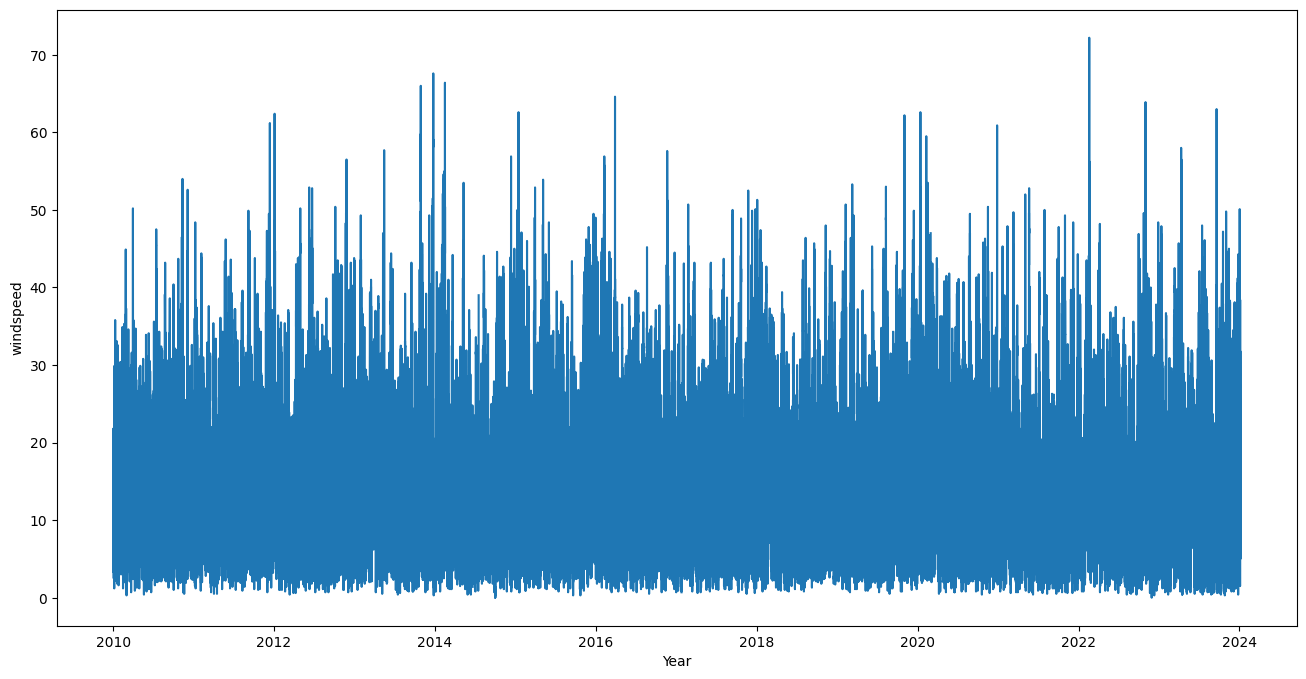

In [8]:
# plot the data. For now we're only going to work on temp_avg, so let's have a look
plt.figure(figsize=(16,8))
plt.plot(merged_df.index, merged_df['windspeed'])
plt.xlabel('Year')
plt.ylabel('windspeed')
_=plt.savefig('./average_temp_plot.pdf', dpi=500)

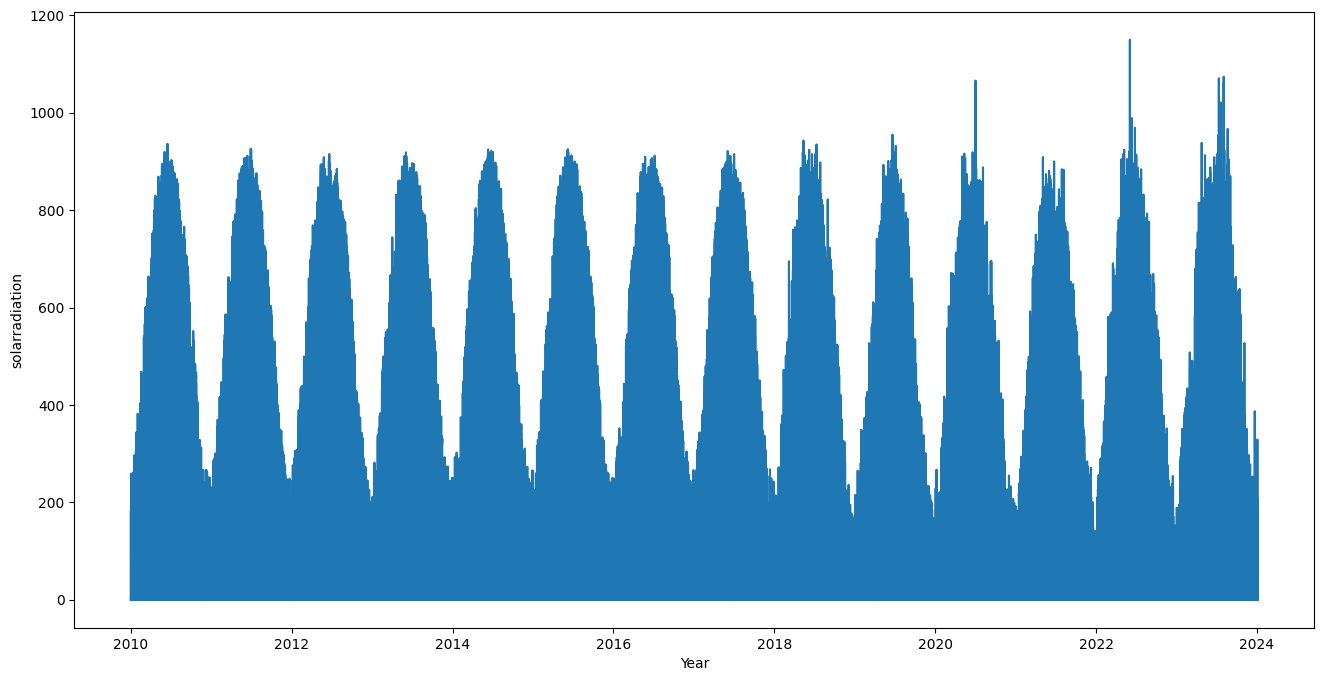

In [9]:
# plot the data. For now we're only going to work on temp_avg, so let's have a look
plt.figure(figsize=(16,8))
plt.plot(merged_df.index, merged_df['solarradiation'])
plt.xlabel('Year')
plt.ylabel('solarradiation')
_=plt.savefig('./average_temp_plot.pdf', dpi=500)

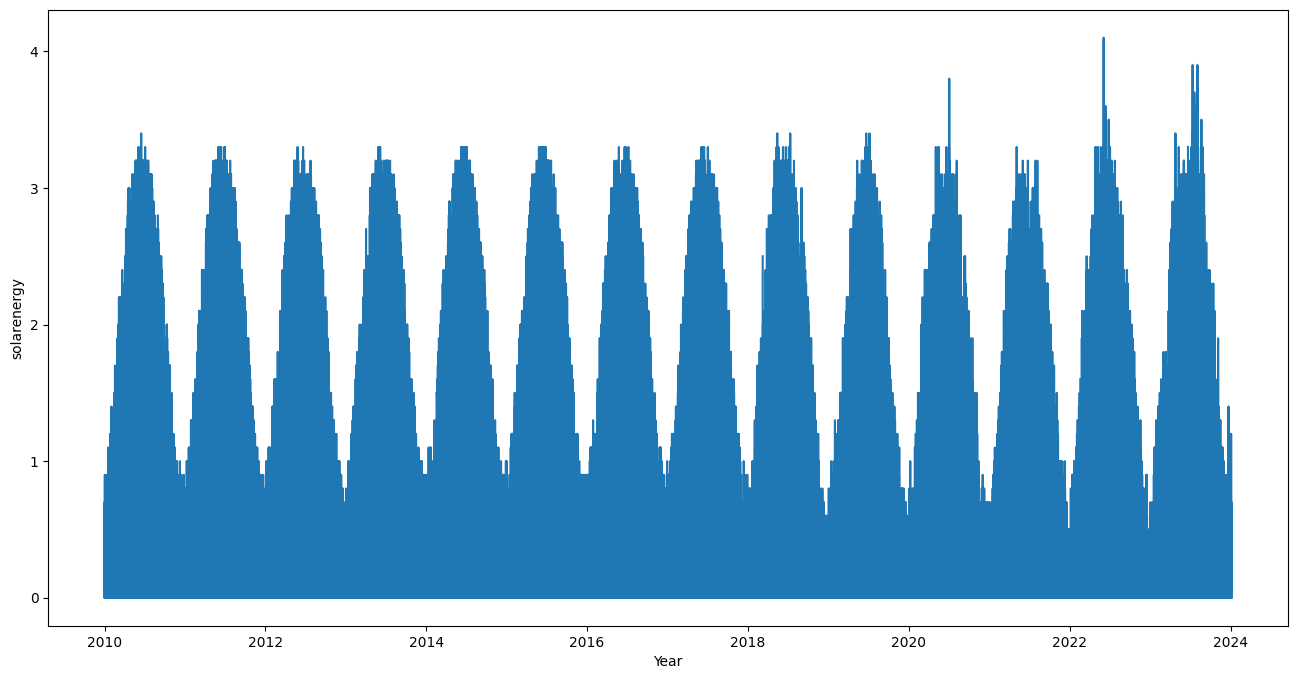

In [10]:
# plot the data. For now we're only going to work on temp_avg, so let's have a look
plt.figure(figsize=(16,8))
plt.plot(merged_df.index, merged_df['solarenergy'])
plt.xlabel('Year')
plt.ylabel('solarenergy')
_=plt.savefig('./average_temp_plot.pdf', dpi=500)

so i have 8 years of data and i notice that there is increase in windspeed, solarenergy as well as solarriadition in 2020 and 2022 so when windspeed go up the other two go up

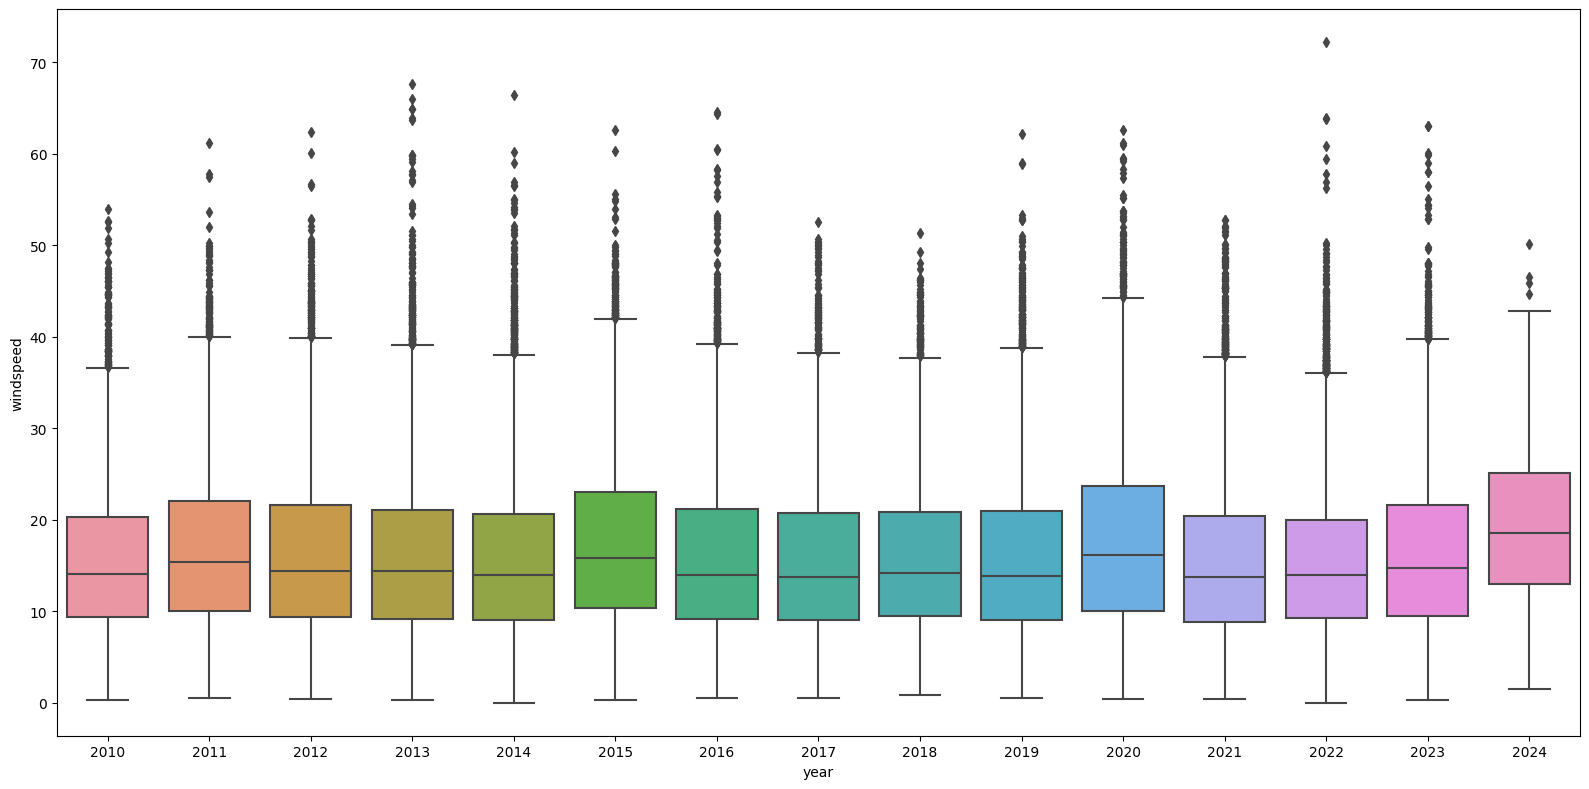

In [11]:
merged_df['year'] = merged_df.index.year
plt.figure(figsize=(16, 8))
_=sns.boxplot(x='year', y='windspeed', data=merged_df)
_=plt.tight_layout()
_=plt.savefig('./stationarity_boxplots_per_year.pdf', dpi=1000)

we can notice that there is a different mean every year and there is a small variation but that does not mean that the data is not stationary because i dont see that there is a trend that all going up or going down

In [12]:
# Split the dataset to a train, validation and test 
train = merged_df[:'2018-12-31 00:00:00']  # First 9 years (2010-2018) for training
validation = merged_df['2019-01-01':'2021-12-31 00:00:00']  # Next 3 years (2019-2021) for validation
test = merged_df['2022-01-01':]  # Remaining for test (from 2022 onwards)

print('Start and end of training set:\t\t', train.index.min(), train.index.max())
print('Start and end of validation set:\t', validation.index.min(), validation.index.max())
print('Start and end of test set:\t\t', test.index.min(), test.index.max())
# Display the shapes of training and test sets
print("Training set shape:", train.shape)
print("Test set shape:", test.shape)
print("validation set shape:", validation.shape)


Start and end of training set:		 2010-01-01 00:00:00 2018-12-31 00:00:00
Start and end of validation set:	 2019-01-01 00:00:00 2021-12-31 00:00:00
Start and end of test set:		 2022-01-01 00:00:00 2024-01-06 11:00:00
Training set shape: (78865, 16)
Test set shape: (17652, 16)
validation set shape: (26281, 16)


In [13]:
# Step 1: Detect missing values
missing_values = train.isnull().sum()  # Count missing values in each column

# Calculate the percentage of missing values for each column
missing_percentage = (train.isnull().sum() / len(merged_df)) * 100

# Display the percentage of missing values for each column and the percentage
print("Percentage of missing values for each column:")
print(missing_percentage)
print("Missing values in each column:\n", missing_values)

Percentage of missing values for each column:
temp                 0.139201
dew                  0.144899
humidity             0.140829
precip               0.133503
precipprob           0.150598
preciptype          59.756276
snow                20.482075
snowdepth           20.480447
windspeed            0.129432
winddir              0.142457
sealevelpressure     0.253167
cloudcover           0.151412
solarradiation       0.130246
solarenergy          0.157924
uvindex              0.142457
year                 0.000000
dtype: float64
Missing values in each column:
 temp                  171
dew                   178
humidity              173
precip                164
precipprob            185
preciptype          73407
snow                25161
snowdepth           25159
windspeed             159
winddir               175
sealevelpressure      311
cloudcover            186
solarradiation        160
solarenergy           194
uvindex               175
year                    0
dtype: int6

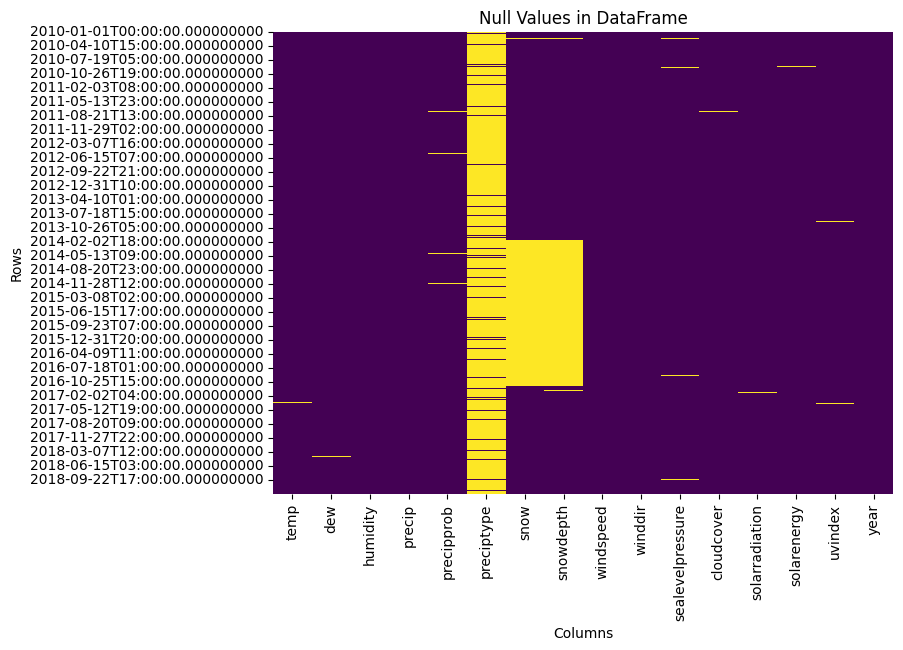

In [14]:
# Plotting null values
plt.figure(figsize=(8, 6))
sns.heatmap(train.isnull(), cmap='viridis', cbar=False)
plt.title('Null Values in DataFrame')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

snow and snowdepth seem to have a great deal of missing value between approximately 2014 and 2017 so we have to fill the missing value with approper method


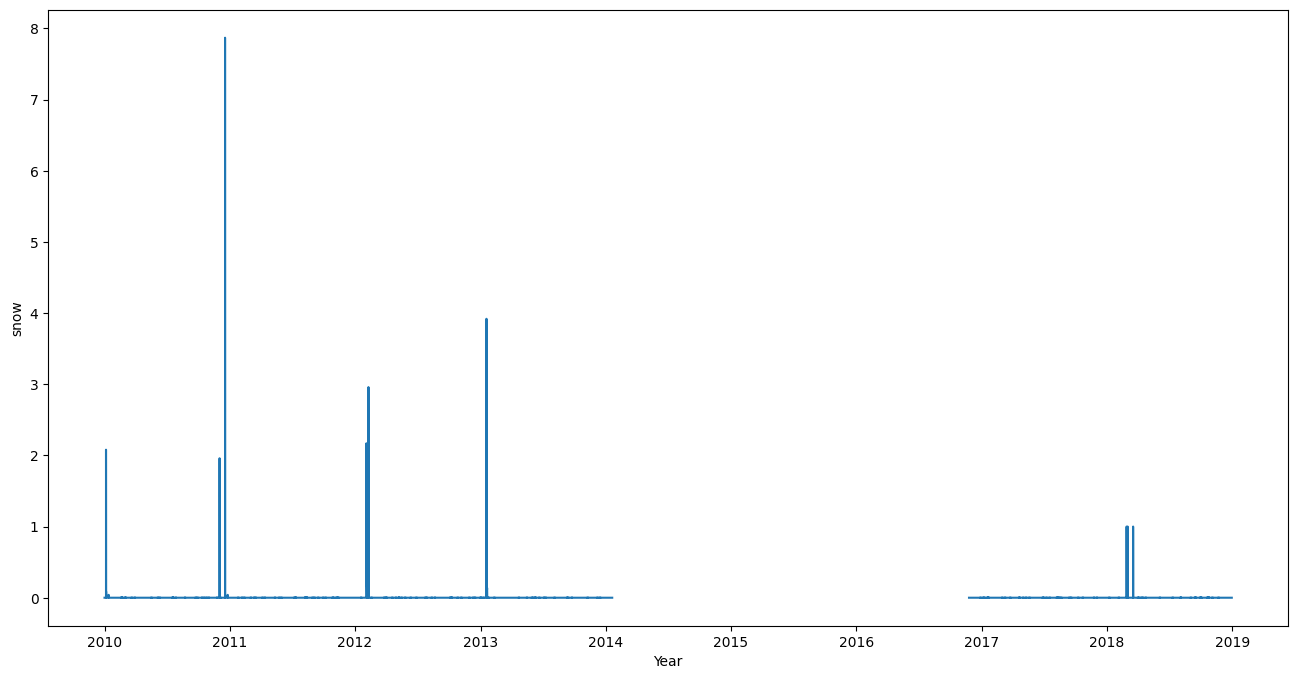

In [15]:
# Let's plot the snow column 
plt.figure(figsize=(16,8))
plt.plot(train.index, train['snow'])
plt.xlabel('Year')
plt.ylabel('snow')
_=plt.savefig('./average_temp_plot.pdf', dpi=500)

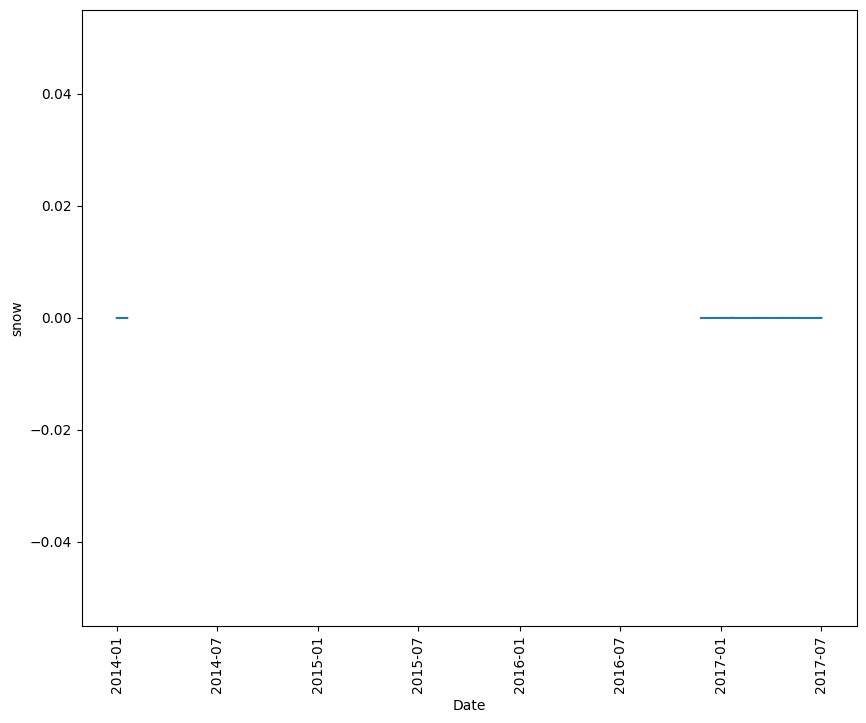

In [16]:
# Let's zoom in to 2016-2017
train_chunk = train.loc['2014-01':'2017-06']  # since the date is an index, we can use it to filter our data

plt.figure(figsize=(10, 8))
plt.plot(train_chunk.index, train_chunk['snow'])
plt.xticks(rotation=90)
plt.xlabel('Date')
_=plt.ylabel('snow')

In [17]:
train['snow'] = train['snow'].interpolate(method='linear')

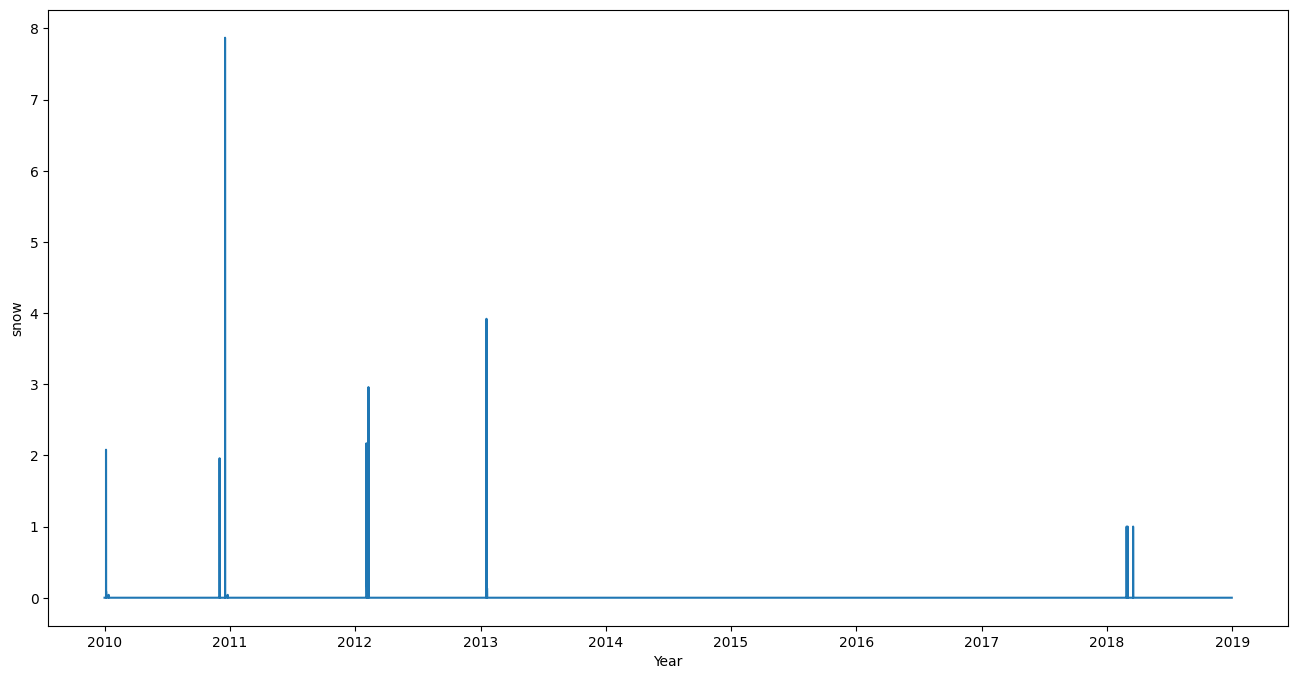

In [18]:
# Let's plot the snow column 
plt.figure(figsize=(16,8))
plt.plot(train.index, train['snow'])
plt.xlabel('Year')
plt.ylabel('snow')
_=plt.savefig('./average_temp_plot.pdf', dpi=500)

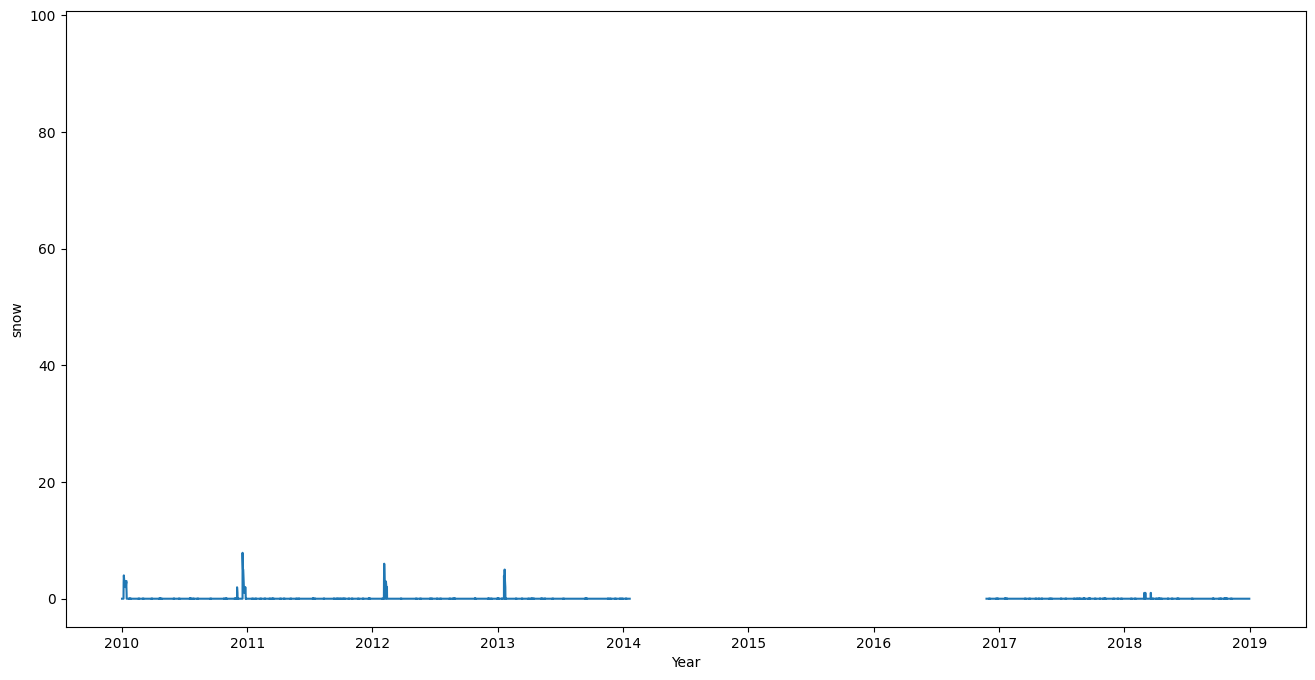

In [19]:
# Let's plot the snow column 
plt.figure(figsize=(16,8))
plt.plot(train.index, train['snowdepth'])
plt.xlabel('Year')
plt.ylabel('snow')
_=plt.savefig('./average_temp_plot.pdf', dpi=500)

In [20]:
# fill snowdepth with zero
train['snowdepth'] = train['snowdepth'].fillna(0)

In [21]:
# dealing with missing values 
# first i will delete perciptype because most of its vlaues missing
train.drop(columns=['preciptype'], inplace=True)

# Display the modified training set
print(train.shape)

(78865, 15)


In [22]:
# Fill missing values in the 'temp' 'dew', 'humidity', 'precip', 'precipprob', 'windspeed'columns using linear
#columns_to_fill = ['temp','dew','humidity','precip','precipprob','windspeed','winddir', 'sealevelpressure','cloudcover','solarradiation','solarenergy','uvindex'] 

#for column in columns_to_fill:
    #train[column] = train[column].interpolate(method='linear')
#missing_values = train.isnull().sum()
train = train.interpolate(method='linear')
# Display the count of missing values for each column
print("Missing values:")
print(missing_values)

Missing values:
temp                  171
dew                   178
humidity              173
precip                164
precipprob            185
preciptype          73407
snow                25161
snowdepth           25159
windspeed             159
winddir               175
sealevelpressure      311
cloudcover            186
solarradiation        160
solarenergy           194
uvindex               175
year                    0
dtype: int64


In [23]:
#sammury state
summary_stats = train.describe()
print(summary_stats)

               temp           dew      humidity        precip    precipprob  \
count  78865.000000  78865.000000  78865.000000  78865.000000  78865.000000   
mean      10.859769      7.926169     83.184618      0.079364      6.919419   
std        5.626445      5.172887     12.139855      0.690037     25.361075   
min       -9.100000    -11.600000     24.340000      0.000000      0.000000   
25%        7.000000      4.300000     75.960000      0.000000      0.000000   
50%       10.900000      8.400000     85.830000      0.000000      0.000000   
75%       15.100000     11.900000     92.870000      0.000000      0.000000   
max       30.900000     19.700000    100.000000     32.385000    100.000000   

               snow     snowdepth     windspeed       winddir  \
count  78865.000000  78865.000000  78865.000000  78865.000000   
mean       0.000440      0.026785     15.913058    195.842834   
std        0.036177      0.450966      8.814026    106.538023   
min        0.000000      0.0

In [24]:
#Note: the code to reindex the full dataframe was giving an error that there were duplicated indices 
# (i.e., some days are repeated). Let's confirm this first.
train[train.index.duplicated(keep=False)].head(20) # keep='False' shows all the duplicates; keep='first' will keep the first one only

,temp,dew,humidity,precip,precipprob,snow,snowdepth,windspeed,winddir,sealevelpressure,cloudcover,solarradiation,solarenergy,uvindex,year
datetime,,,,,,,,,,,,,,,
2010-10-31 01:00:00,12.4,10.6,88.49,0.000,0.0,0.0,0.0,15.0,145.0,996.2,34.1,0.0,0.0,0.0,2010
2010-10-31 01:00:00,12.4,10.3,87.33,0.000,0.0,0.0,0.0,17.9,142.0,996.0,22.4,0.0,0.0,0.0,2010
2011-10-30 01:00:00,14.2,12.3,88.87,0.000,0.0,0.0,0.0,23.8,227.0,1019.3,100.0,0.0,0.0,0.0,2011
2011-10-30 01:00:00,14.4,12.5,88.08,0.000,0.0,0.0,0.0,25.3,227.0,1019.1,100.0,0.0,0.0,0.0,2011
2012-10-28 01:00:00,2.6,0.9,88.68,0.112,100.0,0.0,0.0,15.7,339.0,1020.5,6.2,0.0,0.0,0.0,2012
2012-10-28 01:00:00,2.5,0.7,87.94,0.000,0.0,0.0,0.0,17.5,347.0,1020.4,3.7,0.0,0.0,0.0,2012
2013-10-27 01:00:00,15.0,13.5,90.29,3.592,100.0,0.0,0.0,41.4,211.0,1000.0,75.5,0.0,0.0,0.0,2013
2013-10-27 01:00:00,14.1,13.0,93.01,0.000,0.0,0.0,0.0,35.5,228.0,999.4,84.6,0.0,0.0,0.0,2013
2014-10-26 01:00:00,12.9,9.1,77.71,0.000,0.0,0.0,0.0,6.3,256.0,1022.3,100.0,0.0,0.0,0.0,2014


In [25]:
# Let's keep the first one only
train = train[~train.index.duplicated(keep='first')]
len(train)

78856

In [26]:
import pandas as pd

# Create a date range with hourly frequency from the first date to the last date in the index
full_hourly_range = pd.date_range(start=train.index.min(), end=train.index.max(), freq='H')

# Find missing hours by comparing the full hourly range with the existing hours in the index
missing_hours = full_hourly_range[~full_hourly_range.isin(train.index)]

# Calculate the number of missing hours
num_missing_hours = len(missing_hours)

# Print the number of missing hours
print("Number of missing hours which means rows also:", num_missing_hours)

Number of missing hours which means rows also: 9


In [27]:
import pandas as pd

# Create a date range from the first date to the last date in the index
full_date_range = pd.date_range(start=train.index.min(), end=train.index.max(), freq='H')

# Find missing dates by comparing the full date range with the existing dates in the index
missing_dates = full_date_range[~full_date_range.isin(train.index)]

# Print the missing dates
print("Missing dates:")
print(missing_dates)

Missing dates:
DatetimeIndex(['2010-03-28 01:00:00', '2011-03-27 01:00:00',
               '2012-03-25 01:00:00', '2013-03-31 01:00:00',
               '2014-03-30 01:00:00', '2015-03-29 01:00:00',
               '2016-03-27 01:00:00', '2017-03-26 01:00:00',
               '2018-03-25 01:00:00'],
              dtype='datetime64[ns]', freq=None)


In [28]:
import pandas as pd

# Create a date range with hourly frequency from the first date to the last date in the index
full_hourly_range = pd.date_range(start=train.index.min(), end=train.index.max(), freq='H')

# Reindex the DataFrame to include all the rows in the full date range
train_filled = train.reindex(full_hourly_range)

# Interpolate missing values linearly
train_filled = train_filled.interpolate(method='linear')

# Print the shape of the DataFrame without removing the index name
print(train_filled.shape)  # Note: This will not remove the index name
train_filled.head(10)



(78865, 15)


,temp,dew,humidity,precip,precipprob,snow,snowdepth,windspeed,winddir,sealevelpressure,cloudcover,solarradiation,solarenergy,uvindex,year
2010-01-01 00:00:00,1.9,-0.5,84.25,0.417,100.0,0.0,0.0,19.4,11.0,999.9,62.2,0.0,0.0,0.0,2010.0
2010-01-01 01:00:00,1.9,-0.5,83.90,0.000,0.0,0.0,0.0,21.8,19.0,999.8,22.4,0.0,0.0,0.0,2010.0
2010-01-01 02:00:00,1.4,-0.7,85.76,0.000,0.0,0.0,0.0,17.7,10.0,1000.0,38.0,0.0,0.0,0.0,2010.0
2010-01-01 03:00:00,1.4,-0.7,85.69,0.000,0.0,0.0,0.0,18.0,11.0,1000.2,66.7,0.0,0.0,0.0,2010.0
2010-01-01 04:00:00,1.3,-0.8,85.72,0.000,0.0,0.0,0.0,17.4,10.0,1000.5,62.8,0.0,0.0,0.0,2010.0
2010-01-01 05:00:00,0.6,-1.0,89.01,0.000,0.0,0.0,0.0,15.9,2.0,1000.9,26.3,0.0,0.0,0.0,2010.0
2010-01-01 06:00:00,0.9,-0.7,89.16,0.015,100.0,0.0,0.0,15.4,9.0,1001.3,10.0,0.0,0.0,0.0,2010.0
2010-01-01 07:00:00,0.2,-1.6,87.99,0.000,0.0,0.0,0.0,12.6,360.0,1002.0,10.0,0.0,0.0,0.0,2010.0
2010-01-01 08:00:00,-0.5,-2.2,88.55,0.000,0.0,0.0,0.0,14.3,351.0,1002.5,32.7,23.6,0.1,0.0,2010.0
2010-01-01 09:00:00,-0.6,-2.8,85.40,0.000,0.0,0.0,0.0,14.2,351.0,1003.6,37.8,93.0,0.3,1.0,2010.0


In [29]:
train_filled.drop(columns=['year'], inplace=True)

In [30]:
train.head(5)

,temp,dew,humidity,precip,precipprob,snow,snowdepth,windspeed,winddir,sealevelpressure,cloudcover,solarradiation,solarenergy,uvindex,year
datetime,,,,,,,,,,,,,,,
2010-01-01 00:00:00,1.9,-0.5,84.25,0.417,100.0,0.0,0.0,19.4,11.0,999.9,62.2,0.0,0.0,0.0,2010
2010-01-01 01:00:00,1.9,-0.5,83.90,0.000,0.0,0.0,0.0,21.8,19.0,999.8,22.4,0.0,0.0,0.0,2010
2010-01-01 02:00:00,1.4,-0.7,85.76,0.000,0.0,0.0,0.0,17.7,10.0,1000.0,38.0,0.0,0.0,0.0,2010
2010-01-01 03:00:00,1.4,-0.7,85.69,0.000,0.0,0.0,0.0,18.0,11.0,1000.2,66.7,0.0,0.0,0.0,2010
2010-01-01 04:00:00,1.3,-0.8,85.72,0.000,0.0,0.0,0.0,17.4,10.0,1000.5,62.8,0.0,0.0,0.0,2010


In [31]:
print(train_filled.isna().sum()) 

temp                0
dew                 0
humidity            0
precip              0
precipprob          0
snow                0
snowdepth           0
windspeed           0
winddir             0
sealevelpressure    0
cloudcover          0
solarradiation      0
solarenergy         0
uvindex             0
dtype: int64


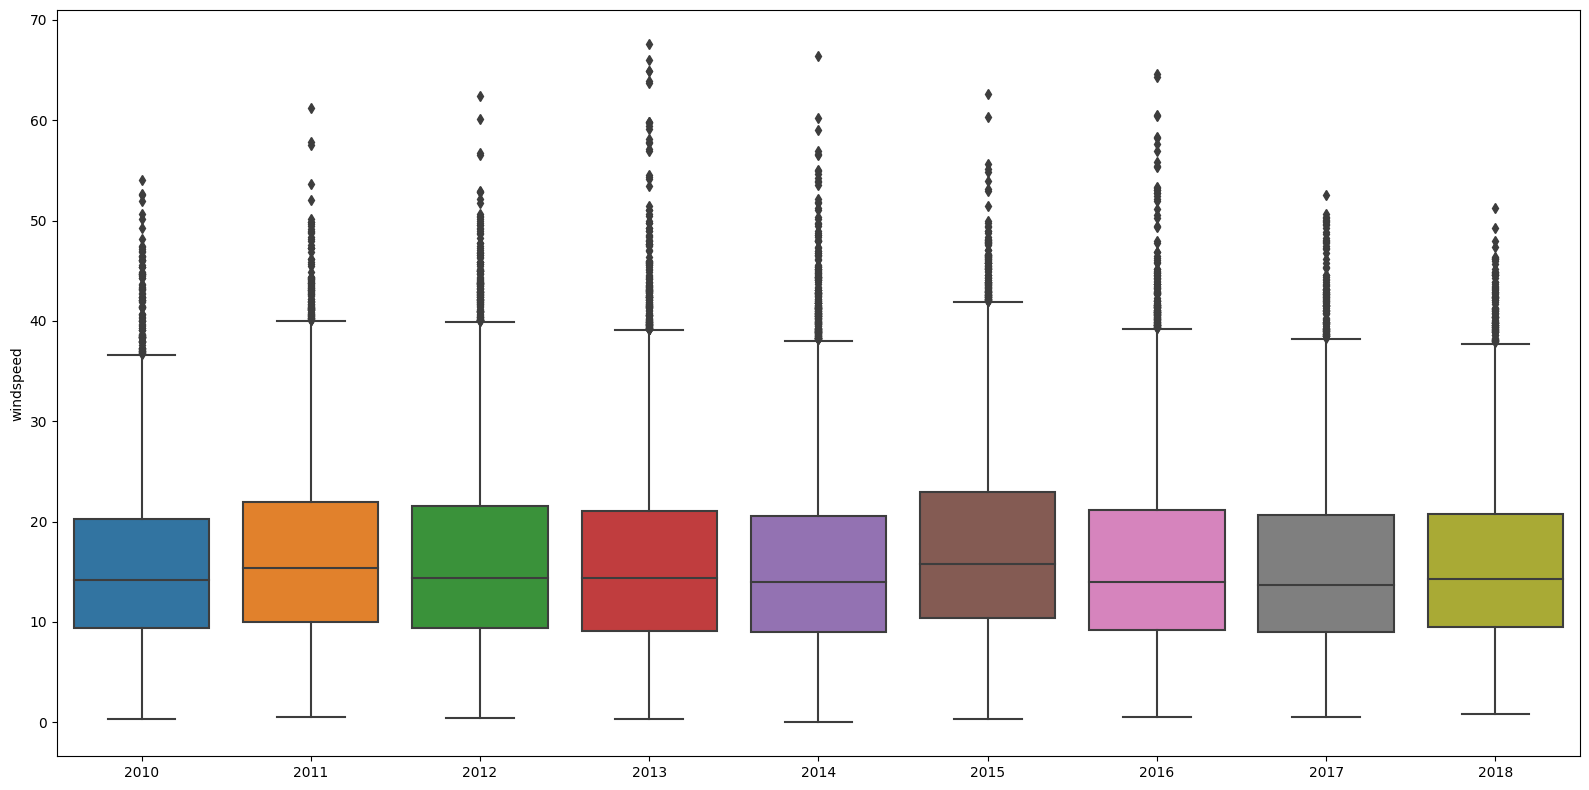

In [32]:
plt.figure(figsize=(16, 8))
sns.boxplot(x=train_filled.index.year, y='windspeed', data=train_filled)
plt.tight_layout()
plt.savefig('./stationarity_boxplots_per_year.pdf', dpi=1000)

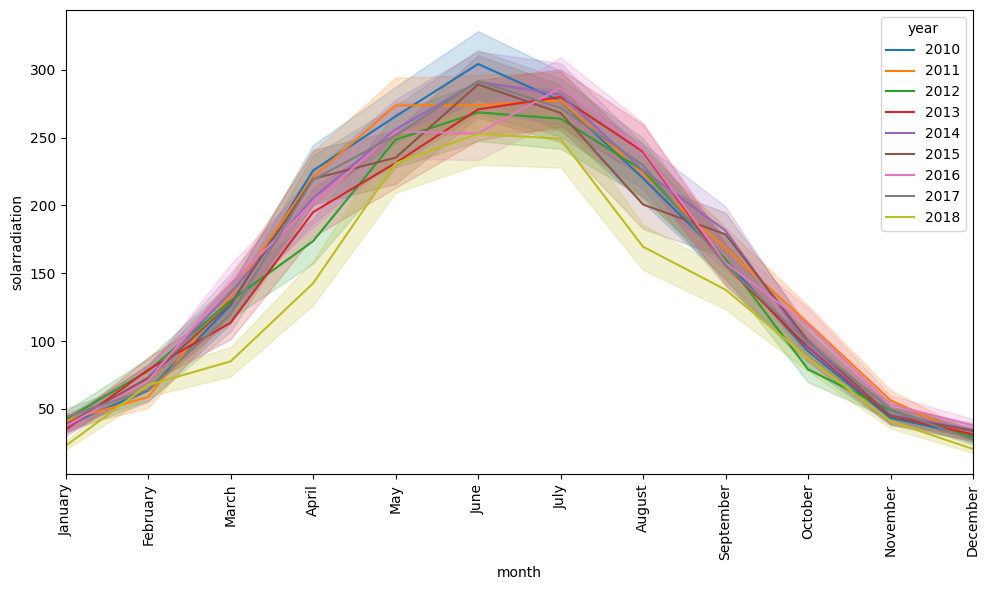

In [33]:
# Visualise trends across years
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Define the list of month names
months_of_the_year = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

# Extract the month from the index and assign it to a new column 'month'
train_filled['month'] = train_filled.index.month

# Check if 'year' column exists in the DataFrame
if 'year' in train_filled.columns:
    # Convert the 'year' column to categorical
    train_filled['year'] = train_filled['year'].astype('category')
else:
    # If 'year' column does not exist, create a new column containing the year component of the index
    train_filled['year'] = train_filled.index.year.astype('category')

# Plot the lineplot with 'month' on the x-axis, 'solarradiation' on the y-axis, and hue as 'year'
plt.figure(figsize=(10, 6))
sns.lineplot(x='month', y='solarradiation', hue='year', data=train_filled)
plt.xticks(np.arange(1, 13), months_of_the_year, rotation=90)  # Set x-axis ticks to month names
plt.xlim(1, 12)  # Limit x-axis to 1-12 (months)
plt.tight_layout()
plt.savefig('./trend_lineplot.pdf', dpi=1000)

we can notice that there is a noticable variation in the warm months where as in the colder monthes there is a small variation 

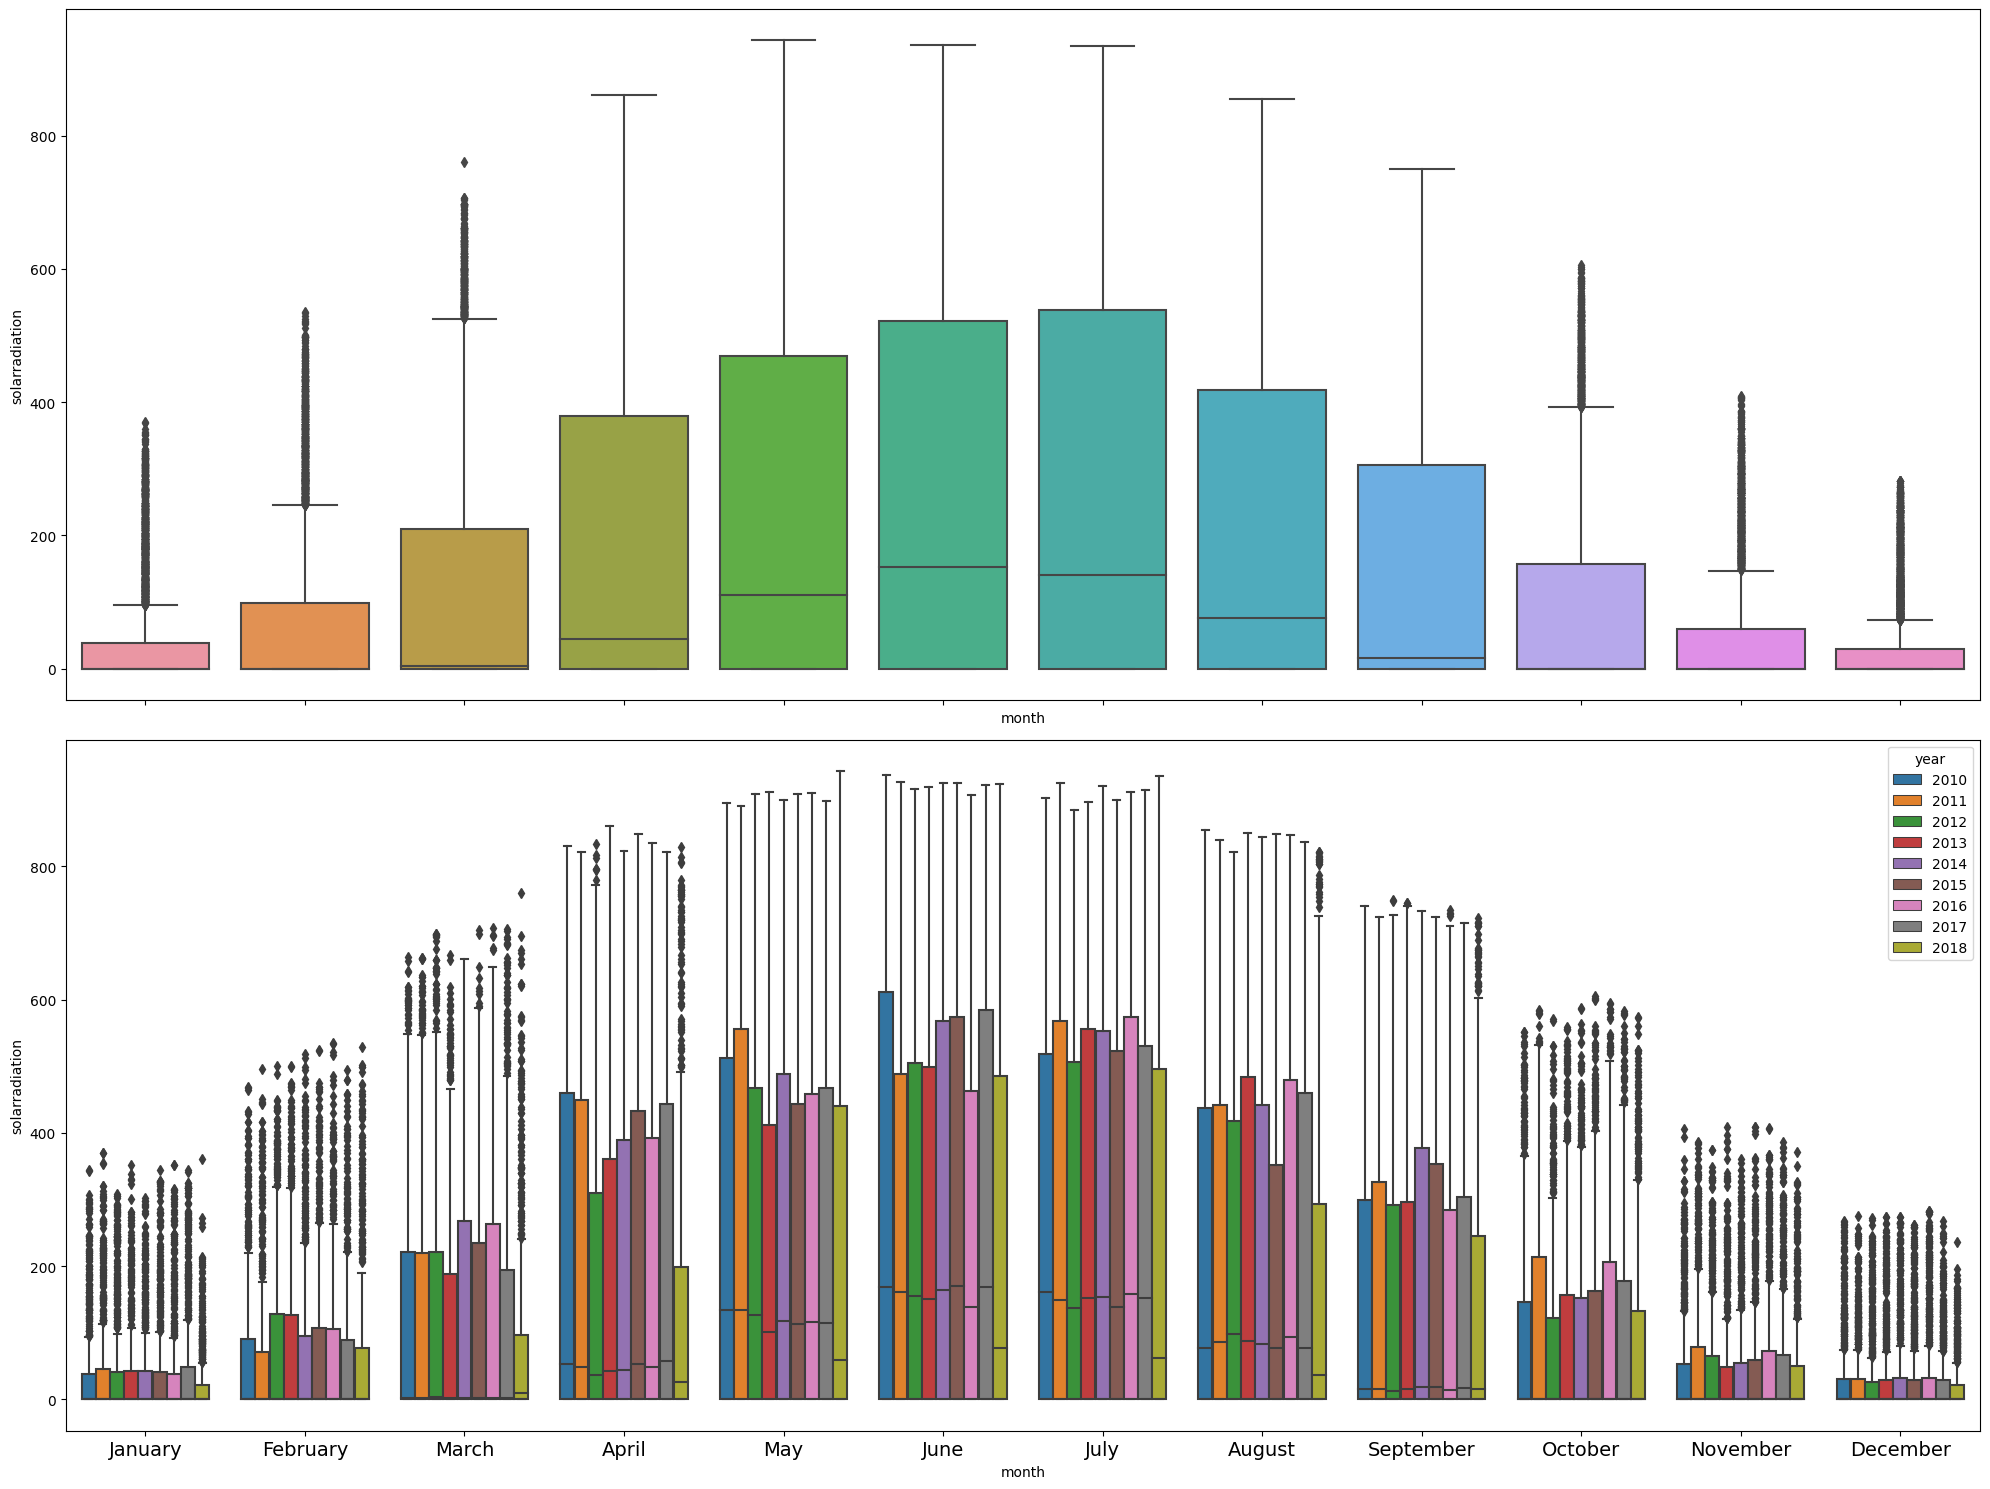

In [34]:
# Visualise trends across years
fix, ax = plt.subplots(2, 1, sharex=True, figsize=(20,15))
sns.boxplot(x='month', y='solarradiation', data=train_filled, ax=ax[0])  # top plot
sns.boxplot(x='month', y='solarradiation', data=train_filled, hue='year', ax=ax[1])  # bottom plot
ax[1].set_xticks(np.arange(0, 12), months_of_the_year, fontsize=14)
plt.tight_layout()
plt.savefig('./trend_boxplots.pdf', dpi=1000)

In [35]:
# Time series decomposition
# Let's downsample our timeseries first: average temperatures per month
data_ds = train_filled['solarradiation'].resample('M').mean().ffill().to_frame()  # one value per month
data_ds

,solarradiation
2010-01-31,37.860887
2010-02-28,63.706845
2010-03-31,126.344355
2010-04-30,225.784722
2010-05-31,265.604368
...,...
2018-08-31,169.538710
2018-09-30,137.877361
2018-10-31,87.558468
2018-11-30,40.983750


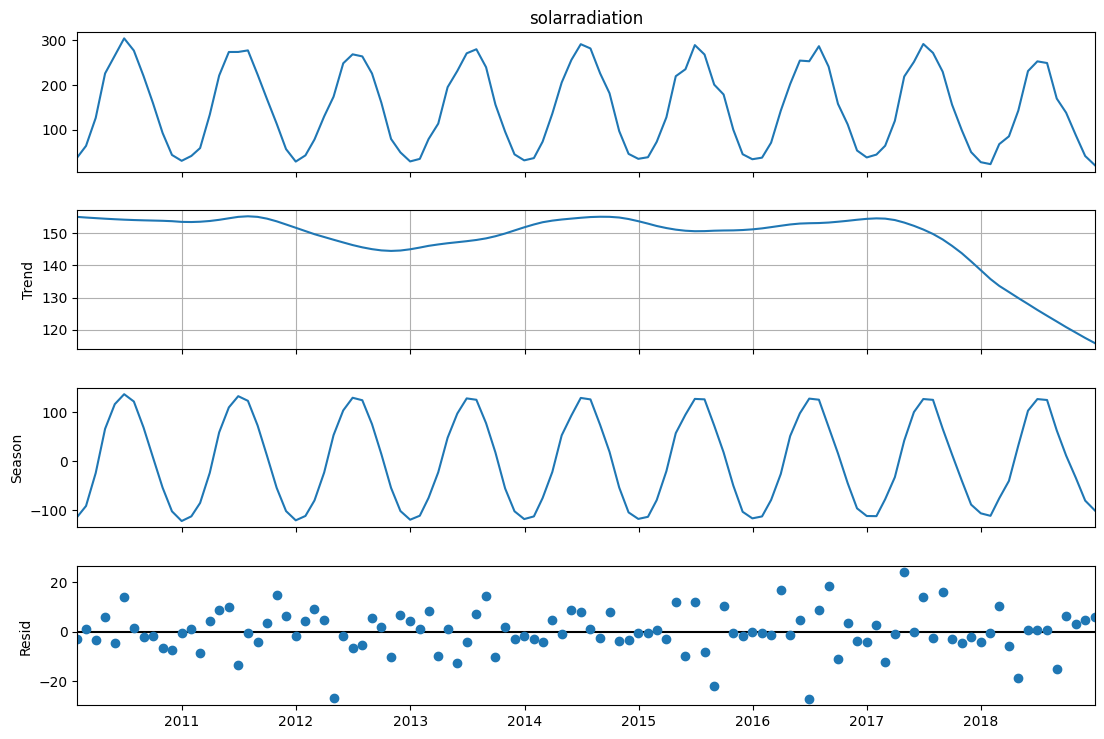

In [36]:
# Try decomposition on the resampled dataset
from statsmodels.tsa.seasonal import STL

decomposition = STL(data_ds['solarradiation']).fit()
fig = decomposition.plot()
fig.set_size_inches(12,8)
fig.axes[1].grid() # so we can check a bit better if there's a trend or not
plt.savefig('./avg_temp_decomp.pdf', dpi=1000)

we can notice from the trend figure that there is not clear trend if i ignore the last two years it looks that it is steady there is no clear go up or down trend
we can notice from season figure that There is a clear seasonal component that repeats yearly.
The residuals are within 2.5 degrees Celsius and most of them  distributed around 0 - that is the noise.

In [37]:
# Statistical test for stationarity: Augmented Dickey-Fuller (ADF) test
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(data_ds['solarradiation'])
print('ADF Statistic %.2f:' % adf_result[0])
print('ADF p-value: %.4f:' % adf_result[1])
# p-value << 0.05 ==> timeseries does not have a unit root

ADF Statistic -0.14:
ADF p-value: 0.9452:


p-value > 0.05 means the time series  have a unit root and it is not stationary.
and from the plot above it is cleaqr that there is periodicity, so the ADF test says it is not stationary.

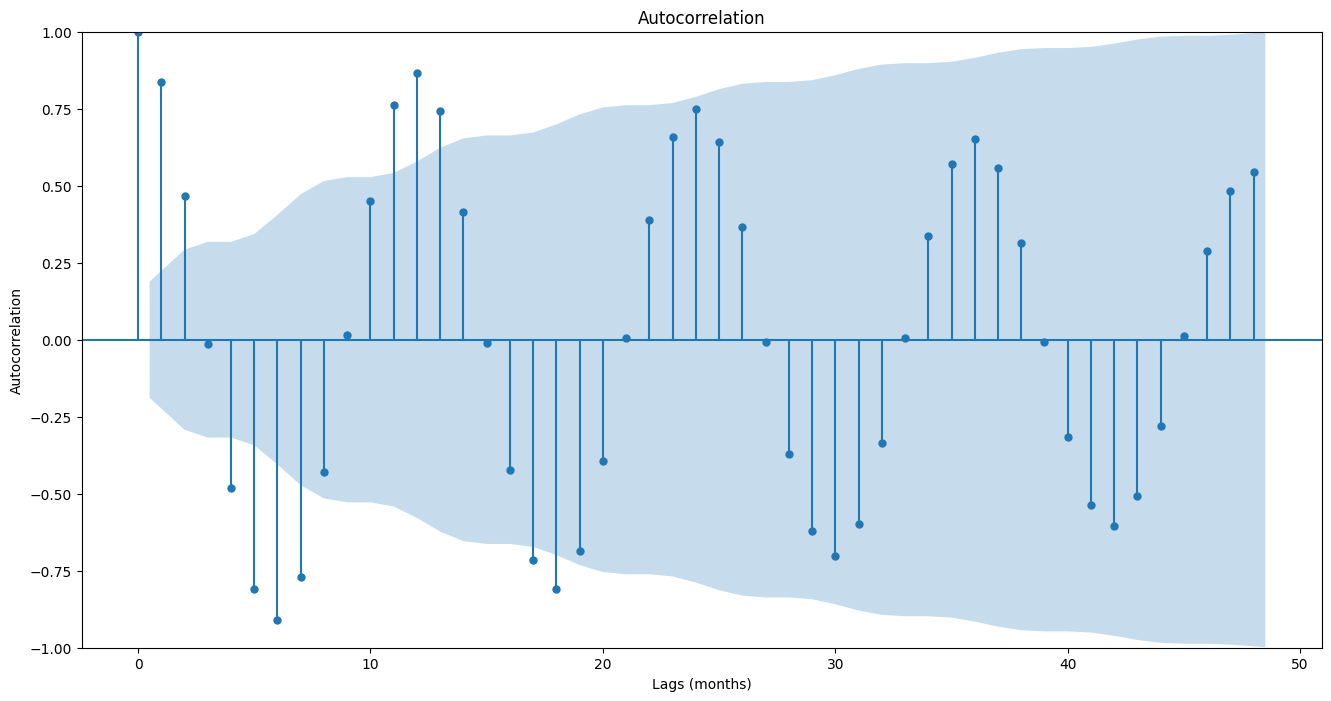

In [38]:
# Autocorrelation 
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
fig, ax = plt.subplots(figsize=(16,8))
_=plot_acf(data_ds['solarradiation'], lags=48, ax=ax)  
_=plt.xlabel('Lags (months)')
_=plt.ylabel('Autocorrelation')
_=plt.savefig('autocorrelation_orig.pdf', dpi=500)

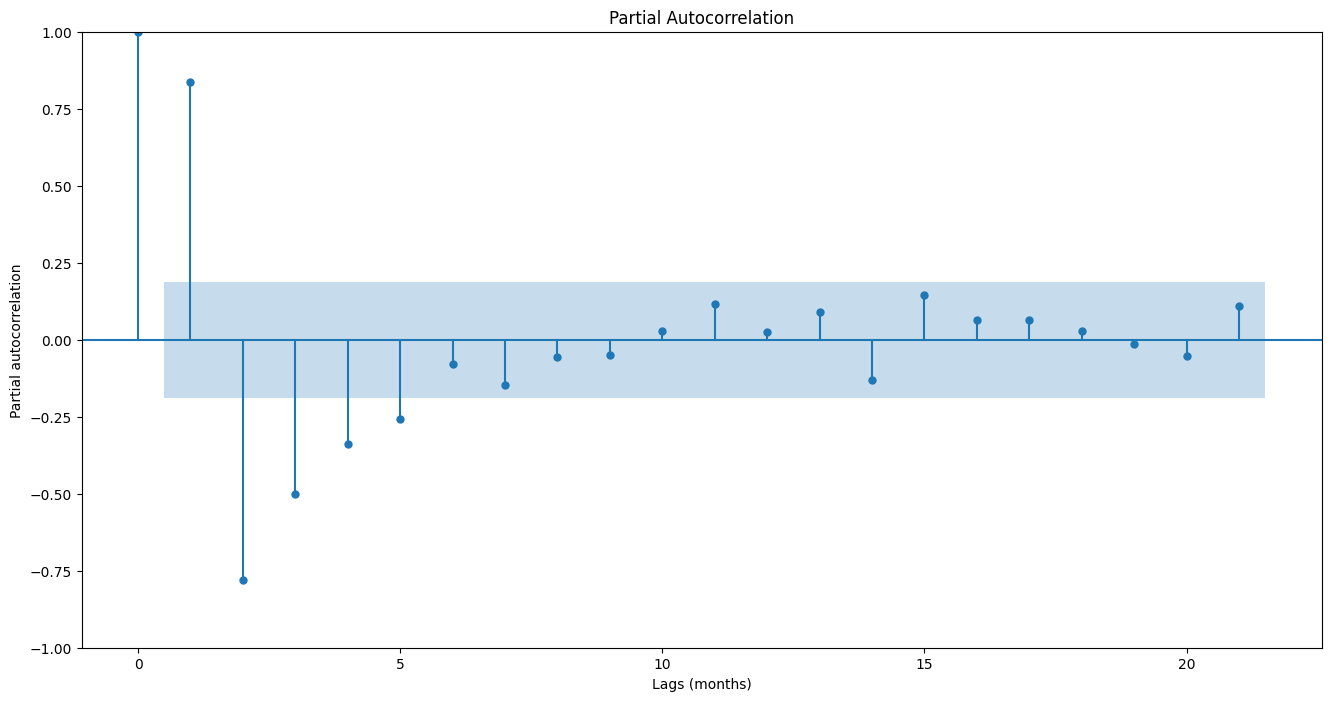

In [39]:
# Partial autocorrelation (can help us with modelling later)
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf
fig, ax = plt.subplots(figsize=(16,8))
_=plot_pacf(data_ds['solarradiation'], ax=ax)
_=plt.xlabel('Lags (months)')
_=plt.ylabel('Partial autocorrelation')
_=plt.savefig('partial_autocorrelation_orig.pdf', dpi=500)

In [40]:
# save this three files in order to use them in the new jupyter
# Save train set to CSV file
train_filled.to_csv('train_filled.csv', index=True)

# Save validation set to CSV file
validation.to_csv('validation.csv', index=True)

# Save test set to CSV file
test.to_csv('test.csv', index=True)